含噪 PSNR: 20.41 dB
Tikhonov PSNR: 19.84 dB
TV PSNR: 25.78 dB


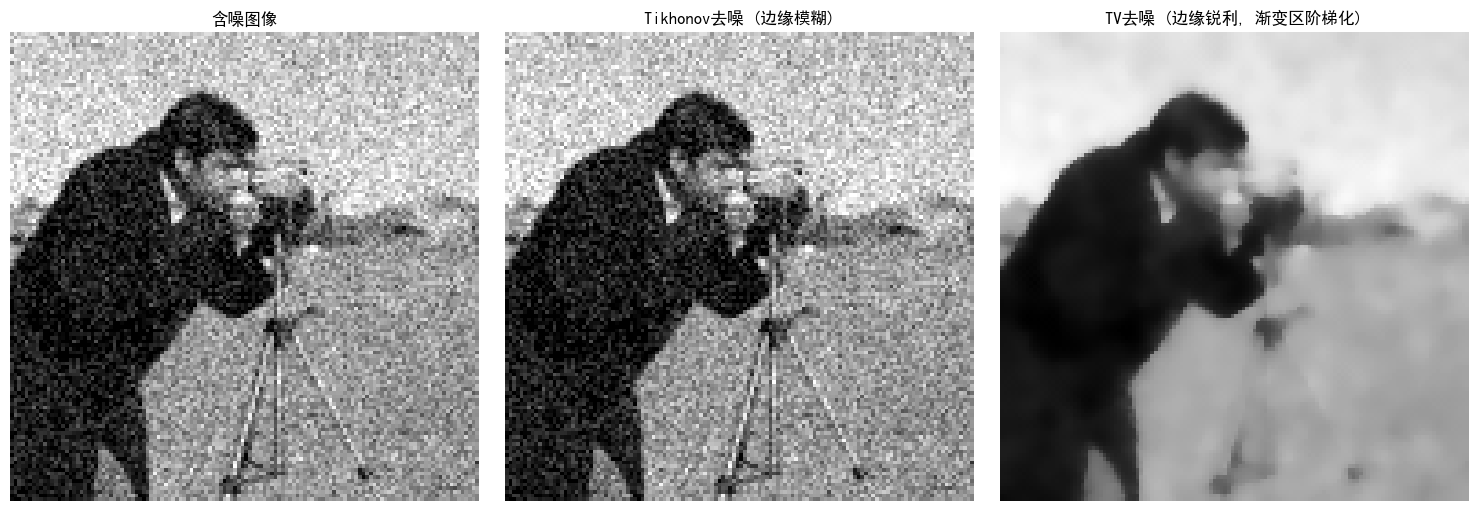

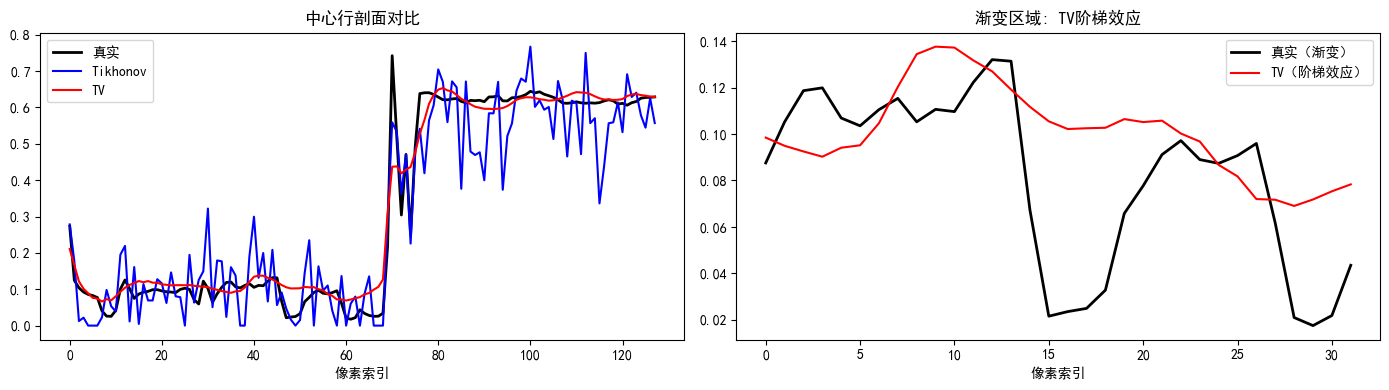

In [1]:
"""
实验2.5 TV去噪：阶梯效应与保边性
对应章节：2.2 TV先验 + 附录2B TGV
知识点：TV保边但产生阶梯效应；TV→分段常数；TGV→分段仿射

素材来源：
  - IP-Img (image_processing.md): denoise_tv_chambolle ROF去噪
  代码取自 IP-Img 的 code-cell (ipython3)
"""

import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import random_noise
from skimage.restoration import denoise_tv_chambolle
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ====== 来源: IP-Img (image_processing.md) ======
# 使用 denoise_tv_chambolle 实现 ROF 模型 TV 去噪

# 加载测试图像 (IP-Img: camera = data.camera())
n = 128
camera = resize(data.camera(), (n, n))

# 加噪 (IP-Img: sigma = .1, random_noise)
sigma = 0.1
camera_noisy = random_noise(camera, mode='gaussian', var=sigma**2)

# TV 去噪 (IP-Img: denoise_tv_chambolle)
alpha = 0.2
camera_filtered = denoise_tv_chambolle(camera_noisy, weight=alpha)

# Tikhonov 去噪对比: x = y / (1 + lambda) (M1)
lam_tikh = 0.1
camera_tikh = camera_noisy / (1 + lam_tikh)

# PSNR 对比
print(f"含噪 PSNR: {peak_signal_noise_ratio(camera, camera_noisy):.2f} dB")
print(f"Tikhonov PSNR: {peak_signal_noise_ratio(camera, camera_tikh):.2f} dB")
print(f"TV PSNR: {peak_signal_noise_ratio(camera, camera_filtered):.2f} dB")

# ====== 可视化 (IP-Img 风格) ======
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

plt.gray()

ax[0].imshow(camera_noisy)
ax[0].set_title('含噪图像')
ax[0].axis('off')

ax[1].imshow(camera_tikh)
ax[1].set_title('Tikhonov去噪 (边缘模糊)')
ax[1].axis('off')

ax[2].imshow(camera_filtered)
ax[2].set_title('TV去噪 (边缘锐利, 渐变区阶梯化)')
ax[2].axis('off')

plt.tight_layout()
plt.savefig('2_5_result.png', dpi=150, bbox_inches='tight')
plt.show()

# ====== 中心行剖面: 观察阶梯效应 ======
row = n // 2
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(camera[row, :], 'k-', linewidth=2, label='真实')
axes[0].plot(camera_tikh[row, :], 'b-', linewidth=1.5, label='Tikhonov')
axes[0].plot(camera_filtered[row, :], 'r-', linewidth=1.5, label='TV')
axes[0].set_title('中心行剖面对比')
axes[0].legend()
axes[0].set_xlabel('像素索引')

# 渐变区域放大（展示TV阶梯效应）
grad_region = slice(n//4, n//2)
axes[1].plot(camera[row, grad_region], 'k-', linewidth=2, label='真实（渐变）')
axes[1].plot(camera_filtered[row, grad_region], 'r-', linewidth=1.5, label='TV（阶梯效应）')
axes[1].set_title('渐变区域: TV阶梯效应')
axes[1].legend()
axes[1].set_xlabel('像素索引')

plt.tight_layout()
plt.savefig('2_5_staircase.png', dpi=150, bbox_inches='tight')
plt.show()
